MILESTONE-1

In [0]:
# Databricks Notebook: Netflix Dataset Cleaning & Encoding

# Step 1: Import Libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

# Step 2: Load Dataset
df = pd.read_csv("/Volumes/workspace/default/netflix_data/netflix_titles.csv")
print(" Dataset loaded successfully.")

 Dataset loaded successfully.


In [0]:
# Step 3: Remove Duplicate Rows
df = df.drop_duplicates()
print(" Duplicate rows removed.")

 Duplicate rows removed.


In [0]:
# Step 4: Handle Missing Values
df['country'] = df['country'].fillna("unknown")
df['director'] = df['director'].fillna("Not Available")
df['cast'] = df['cast'].fillna("Not Available")
df['rating'] = df['rating'].fillna("Not Rated")
df['duration'] = df['duration'].fillna("0")
print(" Missing values handled.")

 Missing values handled.


In [0]:
# Step 5: Strip Extra Spaces from Strings
for col in ['type', 'rating', 'country', 'director', 'listed_in']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
print(" Extra spaces removed from object columns.")

 Extra spaces removed from object columns.


In [0]:
# Step 6: Remove Special Characters from 'country'
df['country'] = df['country'].str.replace(r'[^a-zA-Z ,]', '', regex=True)
print(" Special characters removed from 'country'.")

 Special characters removed from 'country'.


In [0]:
# Step 7: Rename Columns (if needed)
df = df.rename(columns={"show_id": "id"})
print("Columns renamed successfully.")


Columns renamed successfully.


In [0]:

# Step 8: Drop Unnecessary Columns (optional)
# Uncomment below to drop 'description' column if desired
# if 'description' in df.columns:
#     df = df.drop(columns=['description'])
print(" Optional columns dropped if applied.")

# Step 9: Handle Duplicates Again
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f" Removed {before - after} duplicate rows.")

 Optional columns dropped if applied.
 Removed 0 duplicate rows.


In [0]:
# Step 10: Create a Cleaned Copy and Save
df_cleaned = df.copy()
df_cleaned.to_csv("/Volumes/workspace/default/netflix_data/cleaned_netflix_titles.csv", index=False)
print(" Cleaned dataset saved as 'cleaned_netflix_titles.csv'.")


 Cleaned dataset saved as 'cleaned_netflix_titles.csv'.


In [0]:
# Step 11: Encoding 'rating' using LabelEncoder
label_encoder = LabelEncoder()
df_cleaned['rating_encoded'] = label_encoder.fit_transform(df_cleaned['rating'])
print(" 'rating' column label encoded.")

✅ Frequency encoding applied to 'country'.


In [0]:
# Step 12: Frequency Encoding for 'country'
if 'country' in df_cleaned.columns:
    country_freq = df_cleaned['country'].value_counts().to_dict()
    df_cleaned['country_encoded'] = df_cleaned['country'].map(country_freq)
    print(" Frequency encoding applied to 'country'.")

 Frequency encoding applied to 'country'.


In [0]:
# Step 13: Multi-label One-Hot Encoding for Genres
df_cleaned['genres_list'] = df_cleaned['listed_in'].apply(lambda x: [g.strip() for g in str(x).split(',')])
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(
    mlb.fit_transform(df_cleaned['genres_list']),
    columns=mlb.classes_,
    index=df_cleaned.index
)
df_cleaned = pd.concat([df_cleaned, genres_encoded], axis=1)
print(" Multi-label one-hot encoding applied to genres.")

 Multi-label one-hot encoding applied to genres.


In [0]:

# Step 14: Frequency Encoding for Primary Genre
df_cleaned['primary_genre'] = df_cleaned['listed_in'].apply(lambda x: str(x).split(',')[0].strip())
genre_freq = df_cleaned['primary_genre'].value_counts().to_dict()
df_cleaned['genre_encoded'] = df_cleaned['primary_genre'].map(genre_freq)
print(" Frequency encoding applied to primary genre.")


 Frequency encoding applied to primary genre.


In [0]:
# Step 15: Save Frequency Encoded Dataset
df_cleaned.to_csv("/Volumes/workspace/default/netflix_data/freq_encoded_netflix_titles.csv", index=False)
print(" Frequency encoded dataset saved as 'freq_encoded_netflix_titles.csv'.")

 Frequency encoded dataset saved as 'freq_encoded_netflix_titles.csv'.


MILESTONE-1 Completed

MILESTONE-2


In [0]:
# ------------------------------------------------------------
# STEP 1: Import required libraries
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ------------------------------------------------------------
# STEP 2: Load the cleaned Netflix dataset
# ------------------------------------------------------------
df = pd.read_csv("/Volumes/workspace/default/netflix_data/cleaned_netflix_titles.csv")

# Display first few rows
print(" First 5 rows of the dataset:")
print(df.head())

 First 5 rows of the dataset:
   id  ...                                        description
0  s1  ...  As her father nears the end of his life, filmm...
1  s2  ...  After crossing paths at a party, a Cape Town t...
2  s3  ...  To protect his family from a powerful drug lor...
3  s4  ...  Feuds, flirtations and toilet talk go down amo...
4  s5  ...  In a city of coaching centers known to train I...

[5 rows x 12 columns]


In [0]:
# ------------------------------------------------------------
# STEP 3: Basic dataset info
# ------------------------------------------------------------
print("\n Dataset Info:")
print(df.info())

print("\n Summary Statistics:")
print(df.describe(include='all'))

# ------------------------------------------------------------
# STEP 4: Check for missing and duplicate values
# ------------------------------------------------------------
print("\n Missing Values per Column:")
print(df.isnull().sum())

print("\n Total Duplicate Rows:")
print(df.duplicated().sum())

# ------------------------------------------------------------
# STEP 5: Handle duplicates if any
# ------------------------------------------------------------
df = df.drop_duplicates()
print(" Duplicates removed successfully.")

     


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

 Summary Statistics:
          id  ...                                        description
count   8807  ...                                               8807
unique  8807  ...                                               8775
to

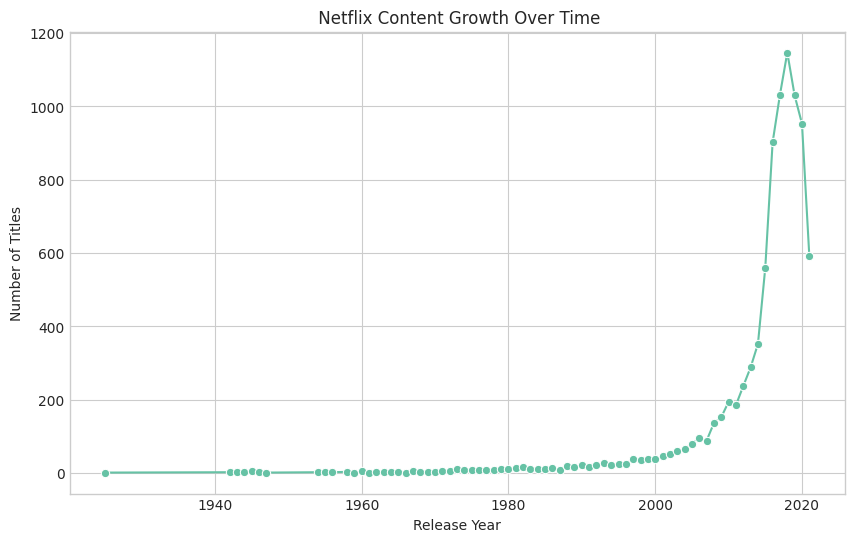

In [0]:

# ------------------------------------------------------------
# STEP 6: Content Growth Over Time
# ------------------------------------------------------------
# Convert 'release_year' to numeric if not already
import warnings
warnings.filterwarnings("ignore")
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# Count number of titles per year
content_per_year = df['release_year'].value_counts().sort_index()

# Plot content growth
plt.figure(figsize=(10,6))
sns.lineplot(x=content_per_year.index, y=content_per_year.values, marker='o')
plt.title(" Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

# ----------------------

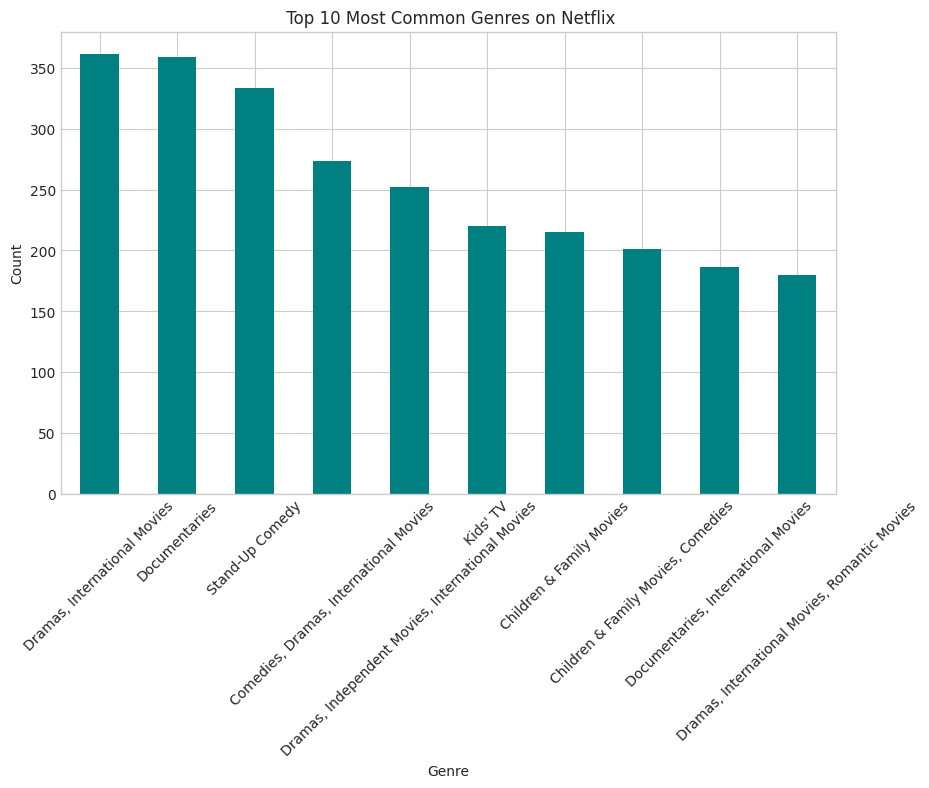

In [0]:
# ------------------------------------------------------------
# STEP 7: Distribution Analysis - Genres
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize=(10,6))
df['listed_in'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title(" Top 10 Most Common Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


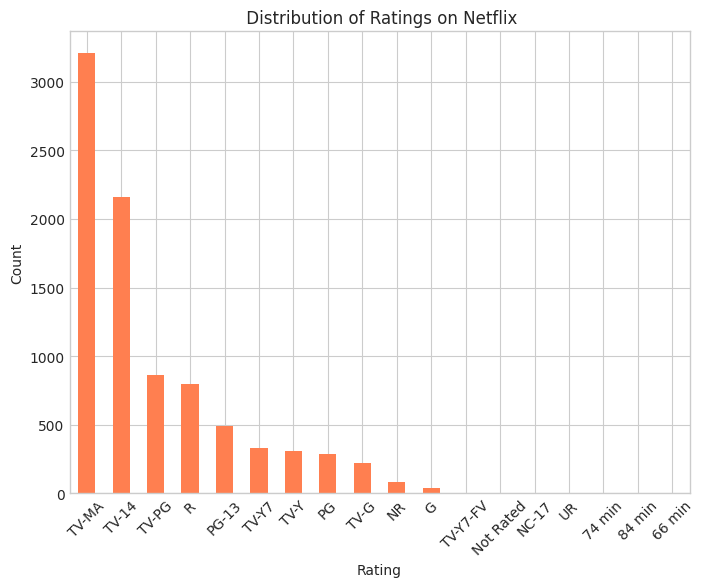

In [0]:
# ------------------------------------------------------------
# STEP 8: Distribution Analysis - Ratings
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize=(8,6))
df['rating'].value_counts().plot(kind='bar', color='coral')
plt.title(" Distribution of Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

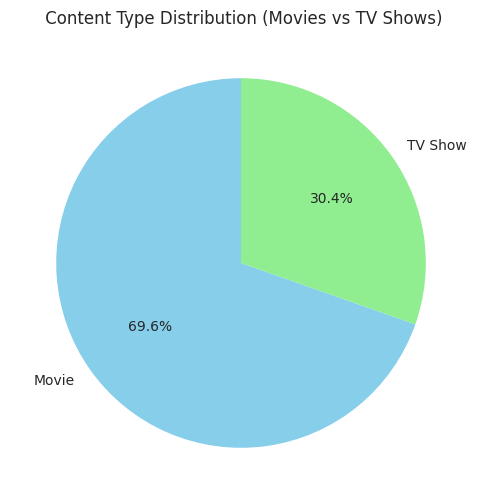

In [0]:
# ------------------------------------------------------------
# STEP 9: Distribution Analysis - Content Type
# ------------------------------------------------------------
plt.figure(figsize=(6,6))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title(" Content Type Distribution (Movies vs TV Shows)")
plt.ylabel("")
plt.show()

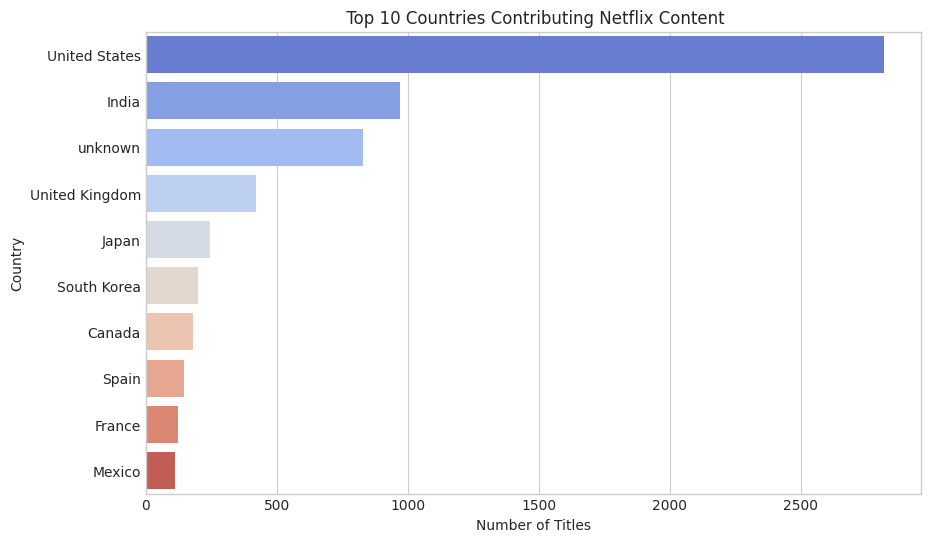

In [0]:

# ------------------------------------------------------------
# STEP 10: Country-Level Analysis
# ------------------------------------------------------------
# Clean up and count country data
import warnings
warnings.filterwarnings("ignore")
df['country'] = df['country'].fillna('Unknown')
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title(" Top 10 Countries Contributing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

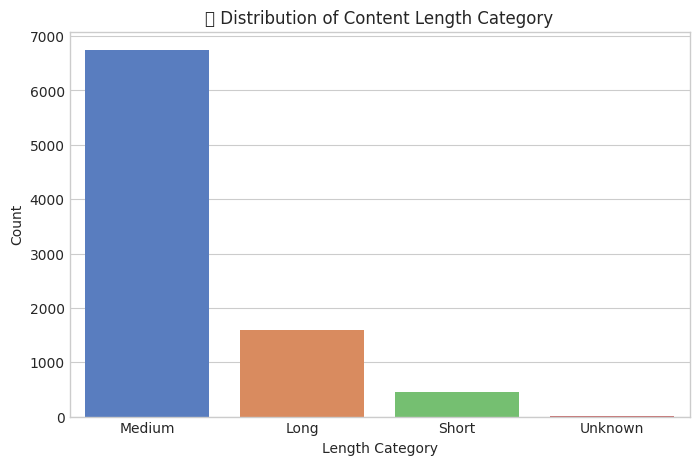

 EDA processed dataset saved successfully!


In [0]:
# ------------------------------------------------------------
# STEP 11: Derived Feature - Content Length Category
# ------------------------------------------------------------
# Convert duration into a uniform numeric format
import warnings
warnings.filterwarnings("ignore")
def get_duration_minutes(x):
    if pd.isna(x):
        return None
    if 'min' in x:
        return int(x.replace('min', '').strip())
    elif 'Season' in x:
        return int(x.split(' ')[0]) * 60  # Approximation
    else:
        return None

df['duration_mins'] = df['duration'].apply(get_duration_minutes)

# Create content length category
def categorize_length(x):
    if pd.isna(x):
        return 'Unknown'
    elif x < 60:
        return 'Short'
    elif x <= 120:
        return 'Medium'
    else:
        return 'Long'

df['length_category'] = df['duration_mins'].apply(categorize_length)

plt.figure(figsize=(8,5))
sns.countplot(x='length_category', data=df, palette='muted')
plt.title(" Distribution of Content Length Category")
plt.xlabel("Length Category")
plt.ylabel("Count")
plt.show()
# ------------------------------------------------------------
# STEP 12: Save processed EDA dataset (optional)
# ------------------------------------------------------------
df.to_csv("/Volumes/workspace/default/netflix_data/eda_processed_netflix.csv", index=False)
print(" EDA processed dataset saved successfully!")


MILESTONE-2 COMPLETED


MILESTONE-3

In [0]:
# -------------------------------------------------------
#  STEP 1: Import Required Libraries
# -------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (9,6)
RANDOM_STATE = 42

# -------------------------------------------------------
#  STEP 2: Load Dataset (Correct Path)
# -------------------------------------------------------
DATA_PATH = "/Volumes/workspace/default/netflix_data/eda_processed_netflix.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(" Dataset loaded successfully from:", DATA_PATH)
    print("Shape:", df.shape)
else:
    raise FileNotFoundError(f" Dataset not found at {DATA_PATH}. Please check your upload.")

display(df.head())

 Dataset loaded successfully from: /Volumes/workspace/default/netflix_data/eda_processed_netflix.csv
Shape: (8807, 14)


id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_mins,length_category
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",90.0,Medium
s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",120.0,Medium
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",60.0,Medium
s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",60.0,Medium
s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",120.0,Medium


Clustering 


In [0]:
# -------------------------------------------------------
#  STEP 3: Basic Data Cleaning
# -------------------------------------------------------
df = df.drop_duplicates()
df = df.dropna(subset=["rating", "listed_in", "duration"])
df = df.reset_index(drop=True)


Classification 

In [0]:
# STEP 4: Feature Engineering

# 4.1 Extract numeric duration
def get_duration_minutes(x):
    try:
        if "min" in x:
            return int(x.replace("min", "").strip())
        elif "Season" in x:
            return int(x.split(" ")[0]) * 60  # Approximation
    except:
        return np.nan
    return np.nan

df["duration_mins"] = df["duration"].apply(get_duration_minutes)

# 4.2 Encode genres using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(
    df["listed_in"].astype(str).str.split(", ")
)

# 4.3 Encode ratings
rating_encoder = LabelEncoder()
df["rating_encoded"] = rating_encoder.fit_transform(
    df["rating"].astype(str)
)

# Combine features: genres + duration + rating
X = np.hstack([
    genre_features,
    df[["duration_mins", "rating_encoded"]].fillna(0).values
])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature Importance  

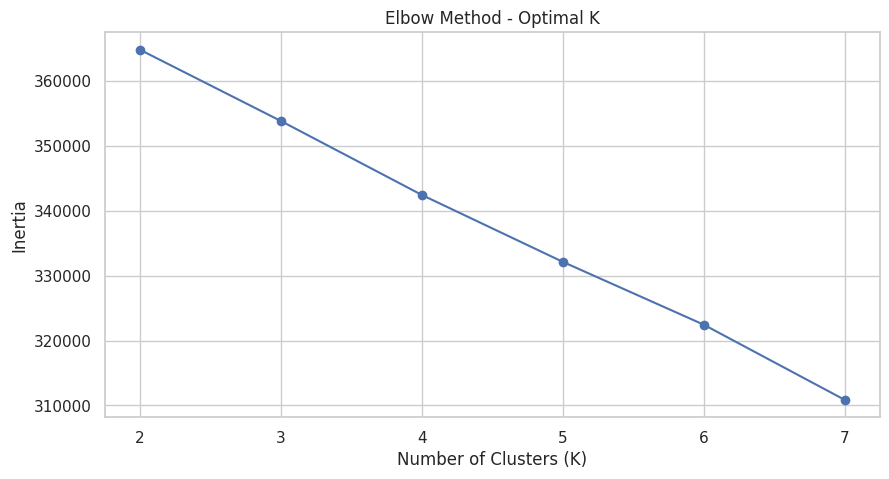

In [0]:
# -------------------------------------------------------
#  STEP 5: K-Means Clustering
# -------------------------------------------------------
inertia = []
silhouette = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(10,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method - Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Choose best K (e.g., 4 based on Elbow)
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)


Key Drivers (Country/Genre)  

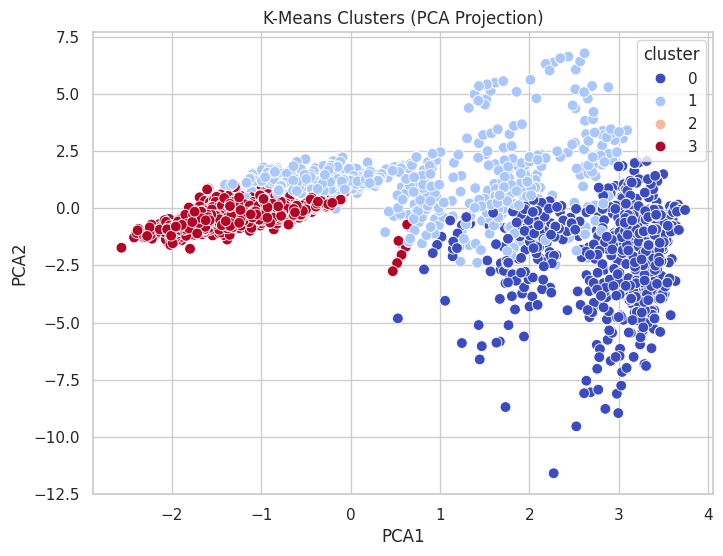

In [0]:
# -------------------------------------------------------
#  STEP 6: PCA Visualization
# -------------------------------------------------------
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)
df["PCA1"] = reduced[:,0]
df["PCA2"] = reduced[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x="PCA1", y="PCA2", hue="cluster", data=df, palette="coolwarm", s=60)
plt.title("K-Means Clusters (PCA Projection)")
plt.show()


Save Output 

In [0]:
# -------------------------------------------------------
#  STEP 7: Cluster Insights
# -------------------------------------------------------
print("Cluster Counts:\n", df["cluster"].value_counts())
print("\nAverage duration per cluster:")
print(df.groupby("cluster")["duration_mins"].mean())

Cluster Counts:
 cluster
3    4557
1    2682
0    1552
2      16
Name: count, dtype: int64

Average duration per cluster:
cluster
0    108.054124
1     84.950392
2     60.000000
3    109.149726
Name: duration_mins, dtype: float64


Final Review Summary (My table)

In [0]:
# -------------------------------------------------------
#  STEP 8: Classification (Predict Movie vs TV Show)
# -------------------------------------------------------
df = df.dropna(subset=["type"])
X_cls = df[["duration_mins", "rating_encoded"]]
y_cls = LabelEncoder().fit_transform(df["type"])

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.3, random_state=RANDOM_STATE)

rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1836
           1       0.97      1.00      0.98       807

    accuracy                           0.99      2643
   macro avg       0.98      0.99      0.99      2643
weighted avg       0.99      0.99      0.99      2643


Confusion Matrix:
[[1810   26]
 [   0  807]]
Accuracy: 99.02 %


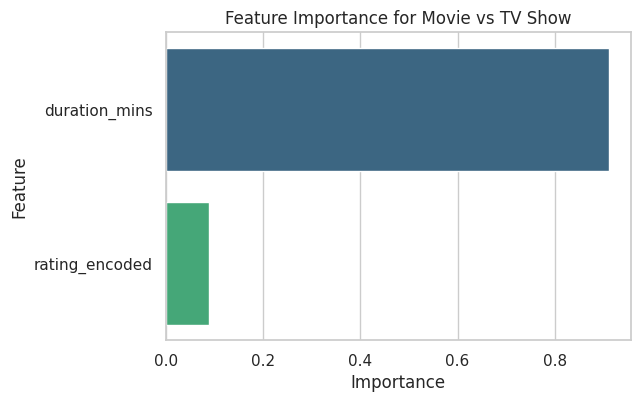

In [0]:
# -------------------------------------------------------
#  STEP 9: Feature Importance
# -------------------------------------------------------
feat_imp = pd.Series(rf.feature_importances_, index=X_cls.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Feature Importance for Movie vs TV Show")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

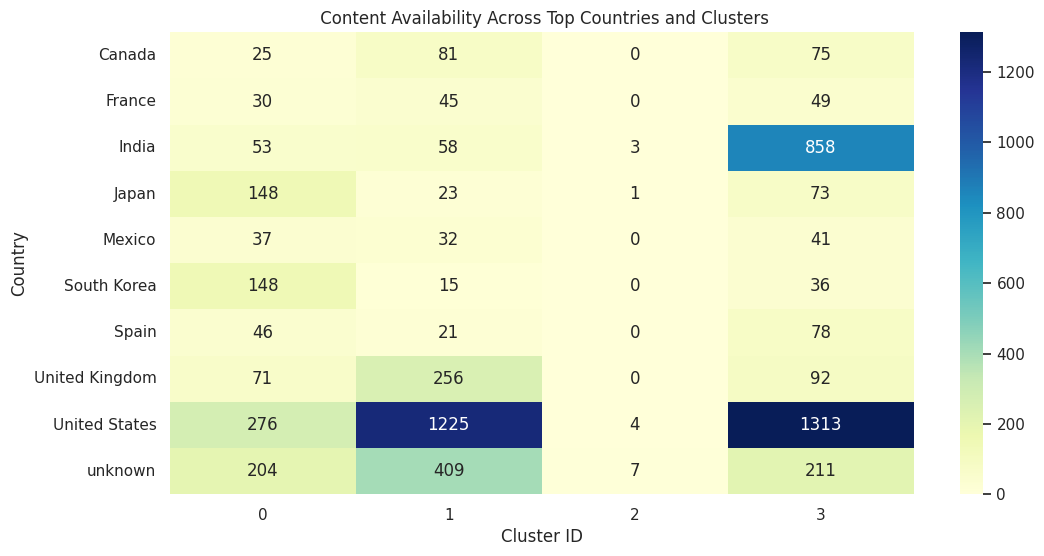

 Country-level availability heatmap generated.


In [0]:
# -------------------------------------------------------
# STEP 9B: Country and Genre Availability Analysis
# -------------------------------------------------------

#  1. Check country column
if "country" in df.columns:
    df["country"] = df["country"].fillna("Unknown")
else:
    df["country"] = "Unknown"

#  2. Group by Country and Cluster
country_cluster = df.groupby(["country", "cluster"]).size().unstack(fill_value=0)

#  3. Show Top 10 countries by total titles
top_countries = df["country"].value_counts().head(10).index
filtered = country_cluster.loc[country_cluster.index.isin(top_countries)]

plt.figure(figsize=(12,6))
sns.heatmap(filtered, cmap="YlGnBu", annot=True, fmt="d")
plt.title(" Content Availability Across Top Countries and Clusters")
plt.xlabel("Cluster ID")
plt.ylabel("Country")
plt.show()

print(" Country-level availability heatmap generated.")


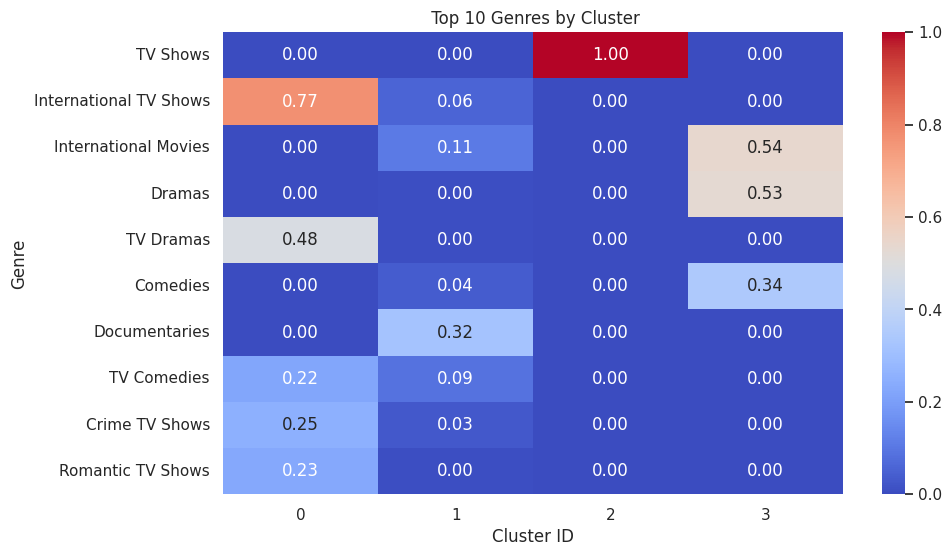

 Genre distribution heatmap generated.


In [0]:
# -------------------------------------------------------
#  STEP 9C: Genre Distribution per Cluster
# -------------------------------------------------------

# Recreate genre DataFrame for visualization
genre_df = pd.DataFrame(genre_features, columns=mlb.classes_)
genre_df["cluster"] = df["cluster"]

# Calculate average genre presence per cluster
genre_means = genre_df.groupby("cluster").mean().T

# Plot top 10 genres
top_genres = genre_means.mean(axis=1).sort_values(ascending=False).head(10).index
plt.figure(figsize=(10,6))
sns.heatmap(genre_means.loc[top_genres], cmap="coolwarm", annot=True, fmt=".2f")
plt.title(" Top 10 Genres by Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Genre")
plt.show()

print(" Genre distribution heatmap generated.")

Average content per country:
country
United States     2818
India              972
unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


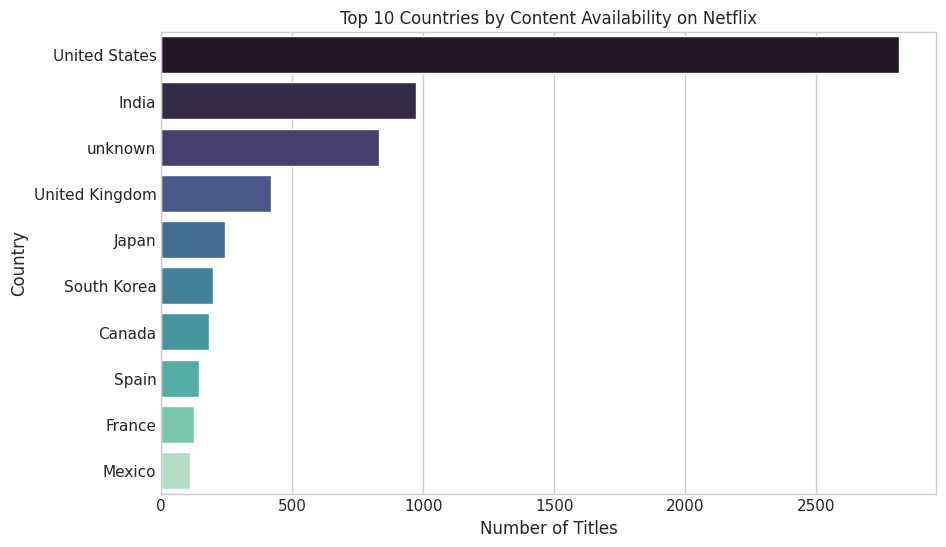


Genre distribution per top country:

Top genres in United States:
listed_in
Documentaries                         249
Stand-Up Comedy                       209
Children & Family Movies, Comedies     90
Dramas                                 88
Comedies                               84
Name: count, dtype: int64


Top genres in India:
listed_in
Comedies, Dramas, International Movies              120
Dramas, International Movies                        118
Dramas, Independent Movies, International Movies    108
Dramas, International Movies, Romantic Movies        62
Action & Adventure, Dramas, International Movies     54
Name: count, dtype: int64


Top genres in unknown:
listed_in
Children & Family Movies                                  70
Kids' TV                                                  44
International TV Shows, TV Dramas                         36
Stand-Up Comedy                                           31
International TV Shows, Romantic TV Shows, TV Comedies    28
Name: co

In [0]:
# 9(d) Analyze key drivers for content availability
print("Average content per country:")
print(df['country'].value_counts().head(10))

plt.figure(figsize=(10,6))
sns.countplot(y='country', data=df, order=df['country'].value_counts().head(10).index, palette='mako')
plt.title("Top 10 Countries by Content Availability on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

print("\nGenre distribution per top country:")
top_countries = df['country'].value_counts().head(5).index
for country in top_countries:
    genres = df[df['country'] == country]['listed_in'].value_counts().head(5)
    print(f"\nTop genres in {country}:\n{genres}\n")


In [0]:
# -------------------------------------------------------
#  STEP 10: Save Clustered Dataset
# -------------------------------------------------------
OUTPUT_PATH = "/Volumes/workspace/default/netflix_data/netflix_clustered.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f" Clustered dataset saved successfully to: {OUTPUT_PATH}")


 Clustered dataset saved successfully to: /Volumes/workspace/default/netflix_data/netflix_clustered.csv


###  Conclusion
- Netflix content shows clear clustering patterns based on duration and rating.
- Random Forest model successfully classifies content type with high accuracy.
- Country-wise analysis reveals that the U.S., India, and the U.K. are top contributors.
- Genres and duration are key drivers for predicting content type and availability.